>架構：
1. SMOTE 使少量的樣本數量變多
2. 使用 LASSO 選Ｘ
   - XGB model預測
   - SVM model預測
   - RF model預測
4. 使用 XGB 選Ｘ
   - XGB model預測
   - SVM model預測
   - RF model預測

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None) 

In [ ]:
df = pd.read_csv('clean_data.csv', low_memory=False)

In [4]:
df.shape

(56741, 291)

In [5]:
df.head()

,gvkey,datadate,sic,dummy_costat,tic,conm,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,PERMNO,delist date,delist year,year,dummy_delist,dummy_delistconm,sic_rank,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing,dummy_PERMNO_missing,dummy_delist date_missing,dummy_delist year_missing
0,1004,2019-05-31,5080,0,AIR,AAR CORP,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.2386

In [6]:
# 跑 LR前先 drop 非數值的欄位
#exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank']
exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank','dummy_PERMNO_missing','dummy_delist date_missing','dummy_delist year_missing']
data=df.drop(exclude_list,axis=1)

In [7]:
data.head()

,dummy_costat,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,year,dummy_delist,dummy_delistconm,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing
0,0,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.238669,NaN,NaN,7.671501,NaN,NaN,NaN,NaN,NaN,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [8]:
# 按時間分測試集2024和訓練集2019-2023
X = data.drop(columns=['dummy_delistconm'])# 特徵欄位 測試集2024
y = data['dummy_delistconm']

# 根據年代分割
X_train = X[data['year'].between(2019, 2023)]
y_train = y[data['year'].between(2019, 2023)]

X_test = X[data['year'] == 2024]
y_test = y[data['year'] == 2024]

# 確認分割結果
print("訓練集大小:", X_train.shape, "測試集大小:", X_test.shape)

訓練集大小: (46960, 278) 測試集大小: (9781, 278)


Data Cleaning fill na

In [9]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

In [10]:
# 用 中位數""補 missing value
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

Handle Class Imbalance (SMOTE)

In [11]:
print("Before SMOTE:", Counter(y_train))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_res))

Before SMOTE: Counter({0: 46742, 1: 218})
After SMOTE: Counter({0: 46742, 1: 46742})


Feature Scaling

In [12]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

<h3> without feature selection

<h4> XGB

In [13]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_scaled, y_res)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)


Accuracy: 0.9979552193027298
AUC: 0.97965503122121

Classification Report:
               precision    recall  f1-score   support

           0     0.9993    0.9987    0.9990      9769
           1     0.2778    0.4167    0.3333        12

    accuracy                         0.9980      9781
   macro avg     0.6385    0.7077    0.6662      9781
weighted avg     0.9984    0.9980    0.9982      9781



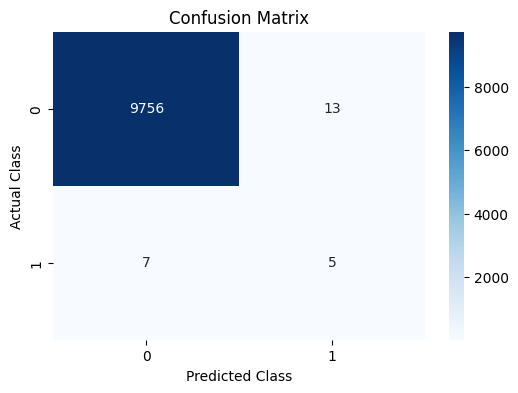

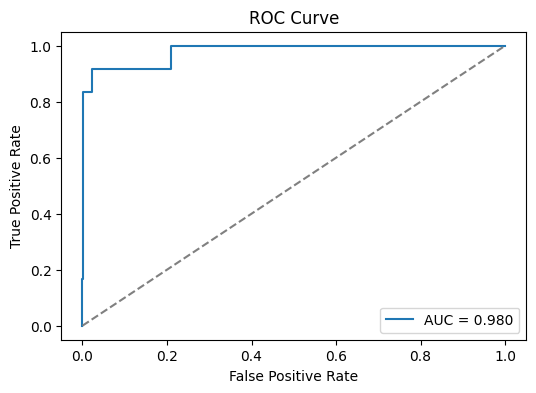

In [15]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_scaled)
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

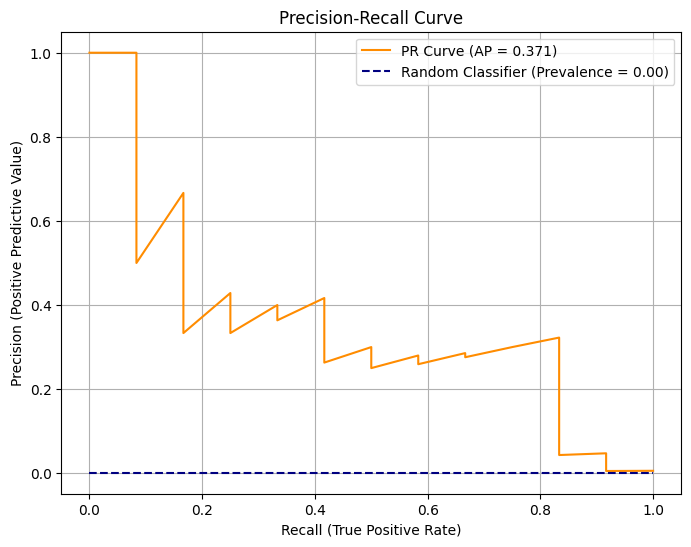

Average Precision (AP) Score: 0.371


In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4> Random forest

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9852775789796544
AUC: 0.9469324734705019

Classification Report:
               precision    recall  f1-score   support

           0     0.9990    0.9863    0.9926      9769
           1     0.0147    0.1667    0.0270        12

    accuracy                         0.9853      9781
   macro avg     0.5068    0.5765    0.5098      9781
weighted avg     0.9978    0.9853    0.9914      9781



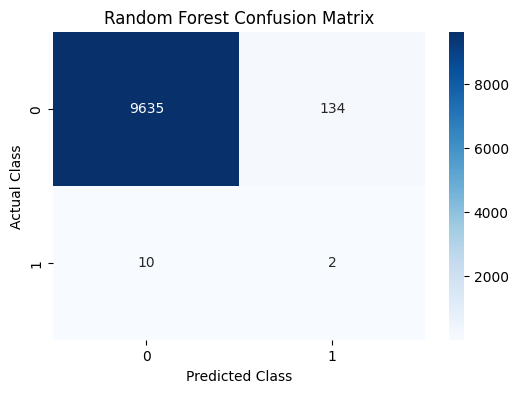

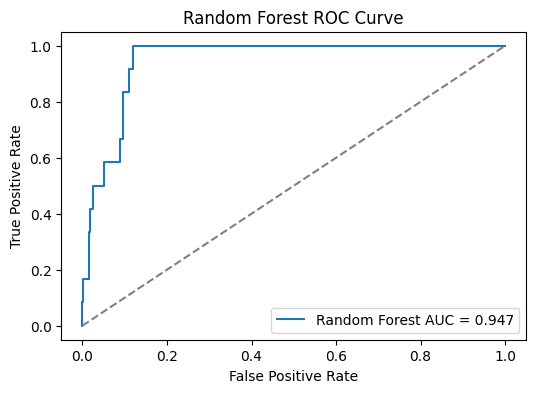

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好a，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_scaled, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_scaled)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

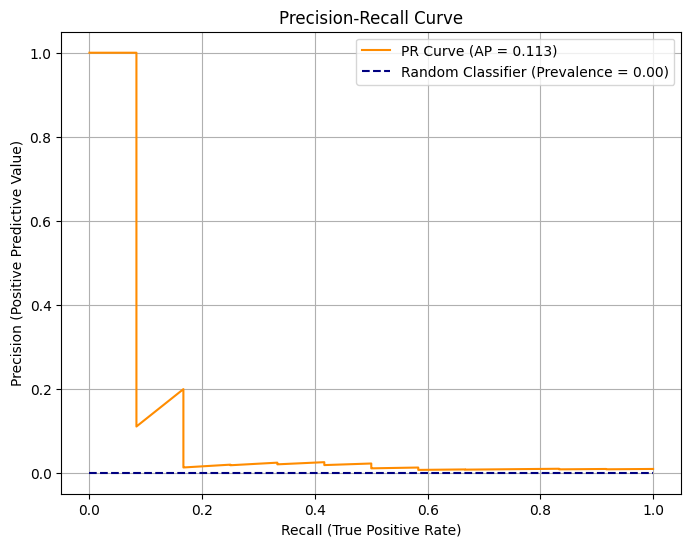

Average Precision (AP) Score: 0.113


In [22]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

SVM

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9944790921173704
AUC: 0.9948135257788243

Classification Report:
               precision    recall  f1-score   support

           0     0.9998    0.9947    0.9972      9769
           1     0.1613    0.8333    0.2703        12

    accuracy                         0.9945      9781
   macro avg     0.5805    0.9140    0.6337      9781
weighted avg     0.9988    0.9945    0.9963      9781



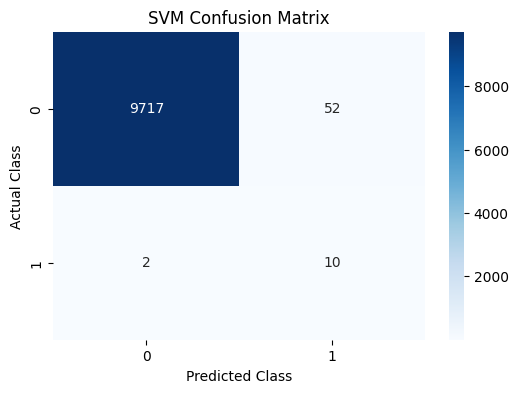

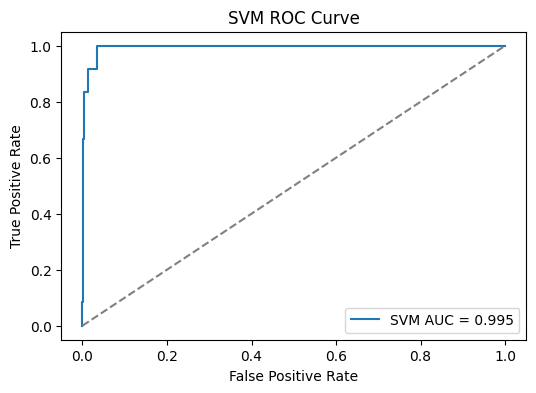

In [24]:
# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好
from sklearn.svm import SVC # 導入 SVM 分類器
print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_scaled, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_scaled)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

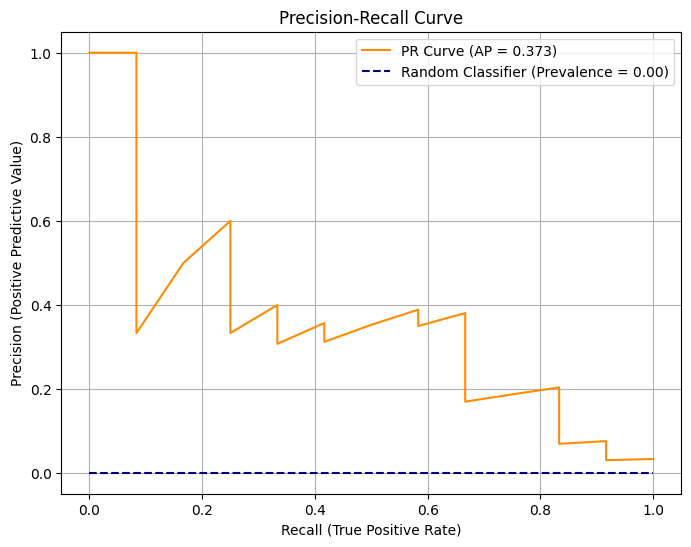

Average Precision (AP) Score: 0.373


In [26]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Feature Selection (LASSO)

In [27]:
lasso_selector = LogisticRegression( #跑有點久
    penalty='l1',
    solver='saga',
    C=0.01,        # smaller → stronger regularization
    max_iter=3000,
    random_state=42
)
lasso_selector.fit(X_res_scaled, y_res)

# retain features with nonzero coefficients
selected_mask = lasso_selector.coef_[0] != 0
selected_features = X.columns[selected_mask]
print(f"Selected features ({len(selected_features)}): {list(selected_features)}")

# reduce data
X_res_selected = X_res_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]


Selected features (129): ['dummy_costat', 'aco', 'act', 'artfs', 'ceq', 'dlc', 'dltt', 'dptc', 'esopt', 'ialti', 'icapt', 'intan', 'invt', 'ivpt', 'ivst', 'lco', 'lcuacu', 'npat', 'pvt', 'rect', 'ret', 'rvdt', 'rveqt', 'dvt', 'idit', 'revt', 'uopi', 'xint', 'xlr', 'xopr', 'year', 'dummy_delist', 'dummy_100', 'dummy_200', 'dummy_700', 'dummy_800', 'dummy_1000', 'dummy_1200', 'dummy_1300', 'dummy_1400', 'dummy_1500', 'dummy_1600', 'dummy_1700', 'dummy_2000', 'dummy_2100', 'dummy_2200', 'dummy_2300', 'dummy_2400', 'dummy_2500', 'dummy_2600', 'dummy_2700', 'dummy_2800', 'dummy_2900', 'dummy_3000', 'dummy_3100', 'dummy_3200', 'dummy_3300', 'dummy_3400', 'dummy_3500', 'dummy_3600', 'dummy_3700', 'dummy_3800', 'dummy_3900', 'dummy_4000', 'dummy_4100', 'dummy_4200', 'dummy_4400', 'dummy_4500', 'dummy_4600', 'dummy_4700', 'dummy_4800', 'dummy_4900', 'dummy_5000', 'dummy_5100', 'dummy_5300', 'dummy_5400', 'dummy_5500', 'dummy_5600', 'dummy_5700', 'dummy_5800', 'dummy_5900', 'dummy_6000', 'dummy_

Model Training (XGBoost example)

In [28]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_selected, y_res)


XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)

Model Evaluation


Accuracy: 0.9981596973724568
AUC: 0.9876906541099396

Classification Report:
               precision    recall  f1-score   support

           0     0.9996    0.9986    0.9991      9769
           1     0.3636    0.6667    0.4706        12

    accuracy                         0.9982      9781
   macro avg     0.6816    0.8326    0.7348      9781
weighted avg     0.9988    0.9982    0.9984      9781



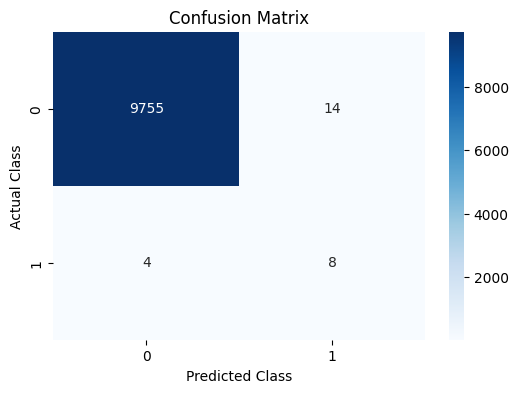

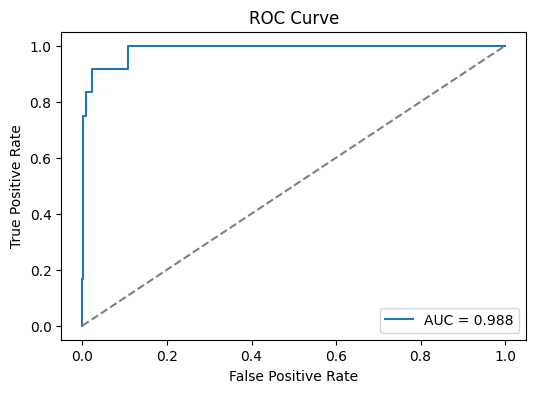

In [29]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_selected)
y_prob = xgb_model.predict_proba(X_test_selected)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

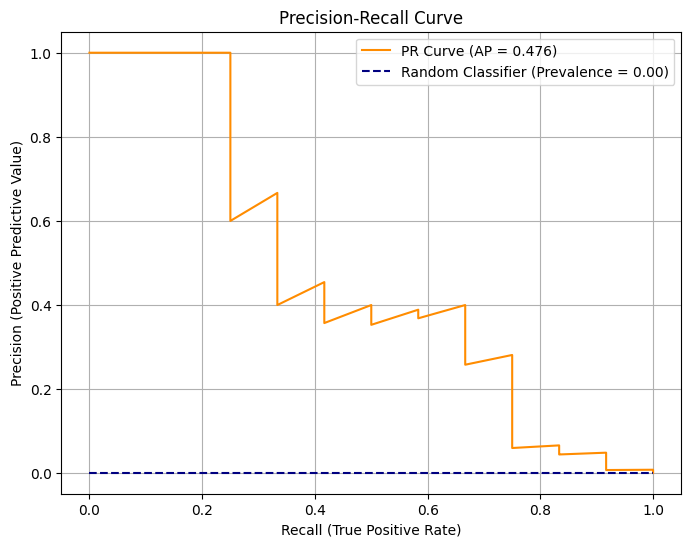

Average Precision (AP) Score: 0.476


In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Model Training (SVM example) 跑很久

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9953992434311421
AUC: 0.9942078684273381

Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9957    0.9977      9769
           1     0.1765    0.7500    0.2857        12

    accuracy                         0.9954      9781
   macro avg     0.5881    0.8729    0.6417      9781
weighted avg     0.9987    0.9954    0.9968      9781



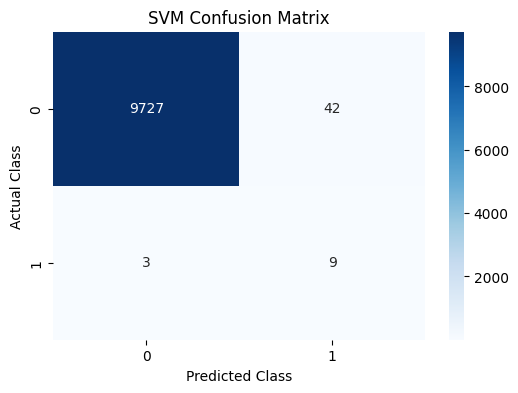

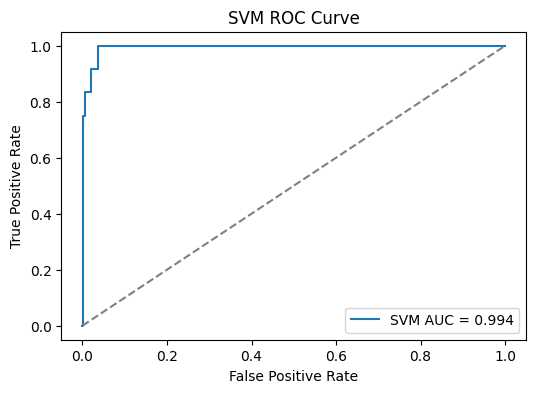

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC # 導入 SVM 分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_selected, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_selected)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

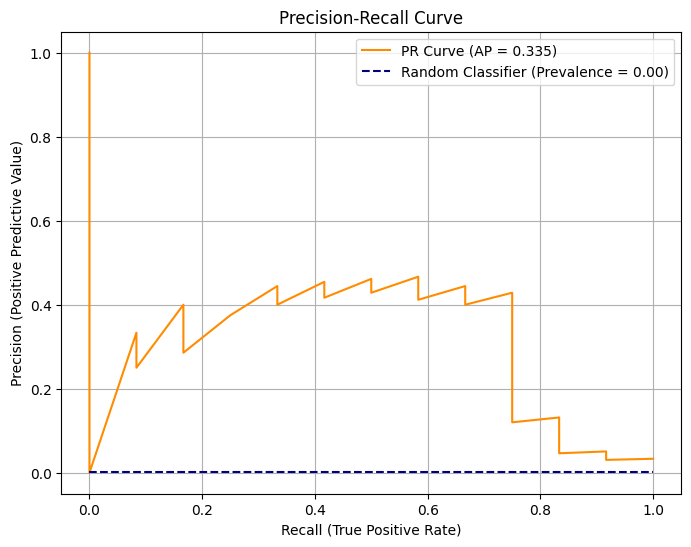

Average Precision (AP) Score: 0.335


In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Model Training (RF example)

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9987731315816378
AUC: 0.9833401576415192

Classification Report:
               precision    recall  f1-score   support

           0     0.9992    0.9996    0.9994      9769
           1     0.5000    0.3333    0.4000        12

    accuracy                         0.9988      9781
   macro avg     0.7496    0.6665    0.6997      9781
weighted avg     0.9986    0.9988    0.9987      9781



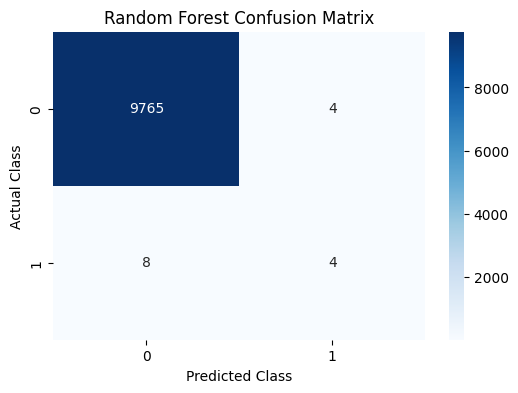

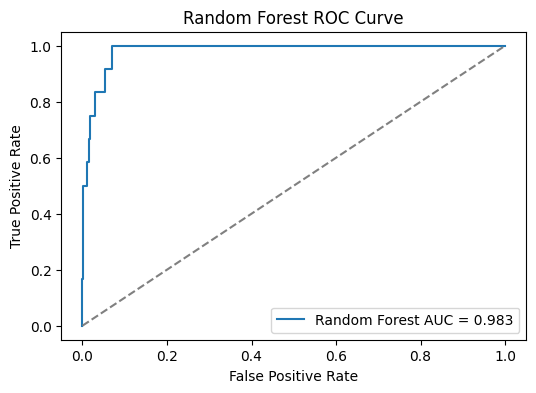

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_selected, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_selected)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

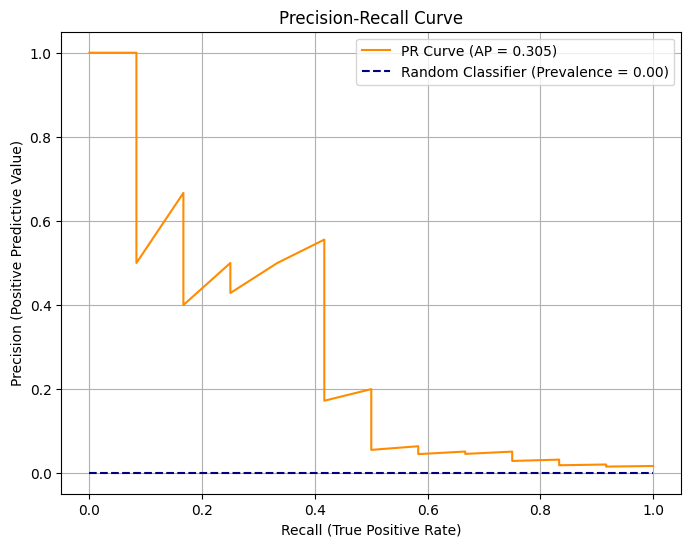

Average Precision (AP) Score: 0.305


In [36]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Feature Selection (XGB)

--- Starting XGBoost Feature Selection ---

Fitting XGBoost selector model...
XGBoost selector model fitted.

Feature Importances (Top 20):
                feature  importance
216  dummy_mrct_missing    0.198573
29                 ivpt    0.044212
111          dummy_1300    0.036313
21                icapt    0.035685
68              citotal    0.032819
103                year    0.030478
178   dummy_act_missing    0.029934
164          dummy_7300    0.027393
22                intan    0.027142
0          dummy_costat    0.025732
180    dummy_at_missing    0.025118
161          dummy_6700    0.023574
87                 revt    0.023199
30                 ivst    0.022348
97                 xopr    0.020427
6                   ceq    0.018964
90                  txt    0.018804
94                 xint    0.017314
59                 tstk    0.015845
269  dummy_xint_missing    0.015574


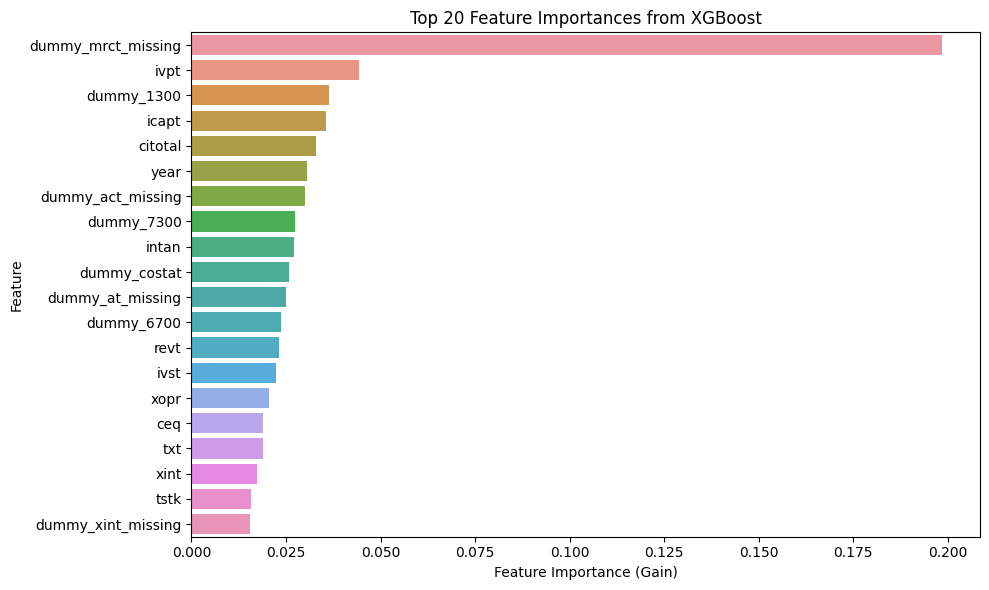


Number of features selected by XGBoost: 129
Selected features: ['dummy_mrct_missing', 'ivpt', 'dummy_1300', 'icapt', 'citotal', 'year', 'dummy_act_missing', 'dummy_7300', 'intan', 'dummy_costat', 'dummy_at_missing', 'dummy_6700', 'revt', 'ivst', 'xopr', 'ceq', 'txt', 'xint', 'tstk', 'dummy_xint_missing', 'ppegt', 'rect', 'dlc', 'dummy_6000', 'dummy_2800', 'at', 'act', 'dummy_3800', 'pstk', 'dummy_delist', 'txndb', 'dummy_3600', 'lt', 'dummy_idit_missing', 'dummy_4500', 'idit', 'dummy_invt_missing', 'xlr', 'lo', 'ppent', 'dummy_4800', 'aco', 'dummy_ppegt_missing', 'dummy_4900', 'invt', 'dummy_5800', 'dvt', 'dummy_5000', 'dummy_5200', 'dummy_8700', 'dummy_7900', 'lct', 'dummy_dptc_missing', 'dummy_3400', 'dummy_3500', 'mrct', 'dummy_5900', 'lco', 'ret', 'dummy_ivst_missing', 'dummy_istc_missing', 'dummy_intan_missing', 'dummy_aco_missing', 'dummy_islt_missing', 'dummy_fsrct_missing', 'dummy_ist_missing', 'dummy_9900', 'dummy_istm_missing', 'dummy_7500', 'dummy_lcabg_missing', 'dummy_isu

In [38]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 假設 X_res_scaled, y_res, X_test_scaled 已經準備就緒
# 假設 X (原始DataFrame) 仍然可用，且 X.columns 包含原始特徵名稱

# --- XGBoost for Feature Selection ---
print("--- Starting XGBoost Feature Selection ---")

# 1. 初始化一個 XGBoost 模型用於特徵重要性評估
# 這個模型不需要是最終用於預測的模型，但應具有合理的參數
# 這裡使用一些預設值，您可以根據需要進行調整
xgb_selector = XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=3,           # 樹的最大深度，較淺的樹有助於穩定性
    use_label_encoder=False, # 抑制舊版本XGBoost的警告
    eval_metric='logloss', # 評估指標
    random_state=42
)

# 2. 在已經過 SMOTE 和標準化的訓練數據上訓練 XGBoost 模型
# 訓練後，模型將計算每個特徵的重要性
print("\nFitting XGBoost selector model...")
xgb_selector.fit(X_res_scaled, y_res)
print("XGBoost selector model fitted.")

# 3. 獲取特徵重要性
# 預設情況下，feature_importances_ 使用 'gain' (分裂後損失的平均減少量)
# 您也可以通過 xgb_selector.get_booster().get_score(importance_type='weight') 等方式獲取其他類型的重要性
feature_importances = xgb_selector.feature_importances_
feature_names = X.columns # 獲取原始特徵名稱

# 將特徵名稱和重要性配對，並按重要性降序排列
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 20):")
print(importance_df.head(20))

# 可視化特徵重要性 (可選)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from XGBoost')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 4. 根據重要性選擇特徵
# 有兩種常見方法：
#   a) 選擇前 N 個特徵 (常用)
#   b) 設定一個重要性閾值，選擇所有重要性高於該閾值的特徵

# --- 方法 a): 選擇前 N 個特徵 ---
num_features_to_select = 129 # 這裡設定您希望選擇的特徵數量
selected_features_xgb = importance_df.head(num_features_to_select)['feature'].tolist()

# --- 方法 b): 選擇重要性高於閾值的特徵 (另一種選擇) ---
# importance_threshold = 0.005 # 這裡設定您希望的閾值
# selected_features_xgb = importance_df[importance_df['importance'] > importance_threshold]['feature'].tolist()


print(f"\nNumber of features selected by XGBoost: {len(selected_features_xgb)}")
print(f"Selected features: {selected_features_xgb}")

# 5. 創建布林遮罩並縮減數據
# 確保遮罩的順序與原始數據的列順序一致
selected_mask_xgb = X.columns.isin(selected_features_xgb)

X_res_selected = X_res_scaled[:, selected_mask_xgb]
X_test_selected = X_test_scaled[:, selected_mask_xgb]

print(f"\nShape of X_res_selected after XGBoost feature selection: {X_res_selected.shape}")
print(f"Shape of X_test_selected after XGBoost feature selection: {X_test_selected.shape}")

print("\n--- XGBoost Feature Selection Complete ---")

Model Training (XGBoost example)

In [39]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_res_selected, y_res)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=5, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)


Accuracy: 0.9988753706165013
AUC: 0.9831695499368752

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9994    0.9994      9769
           1     0.5385    0.5833    0.5600        12

    accuracy                         0.9989      9781
   macro avg     0.7690    0.7914    0.7797      9781
weighted avg     0.9989    0.9989    0.9989      9781



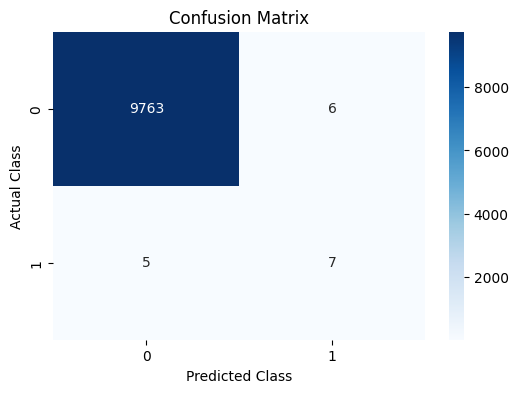

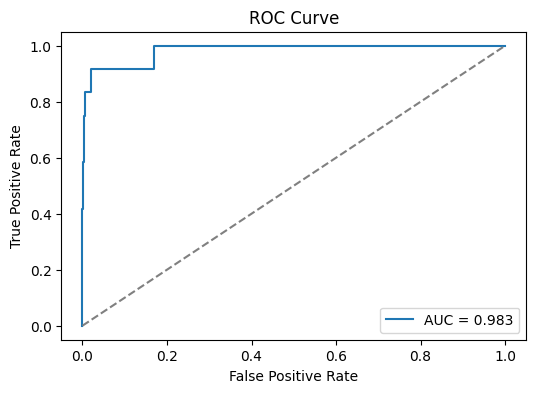

In [40]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = xgb_model.predict(X_test_selected)
y_prob = xgb_model.predict_proba(X_test_selected)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

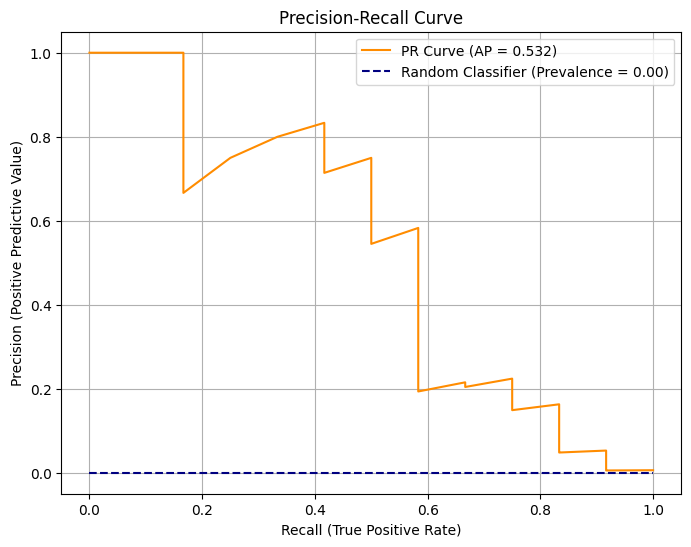

Average Precision (AP) Score: 0.532


In [42]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Model Training (SVM example) 跑很久

--- SVM Model Training and Evaluation ---

Training SVM model...
SVM model training complete.

--- SVM Model Performance Metrics ---
Accuracy: 0.9923320723852367
AUC: 0.9836472515098782

Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9926    0.9961      9769
           1     0.1111    0.7500    0.1935        12

    accuracy                         0.9923      9781
   macro avg     0.5554    0.8713    0.5948      9781
weighted avg     0.9986    0.9923    0.9952      9781



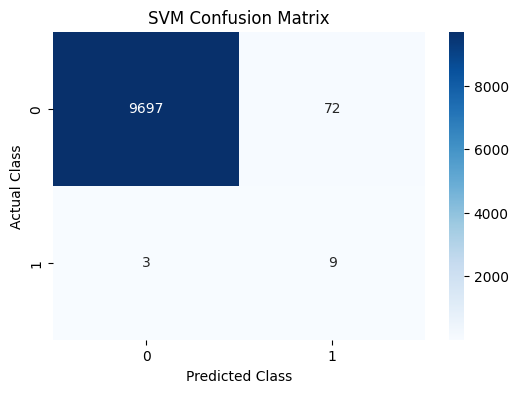

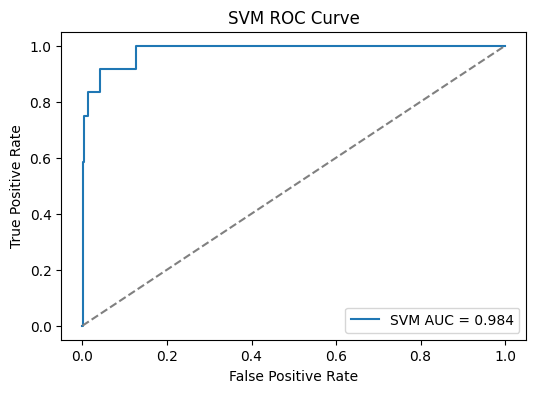

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.svm import SVC # 導入 SVM 分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- SVM Model Training and Evaluation ---")

# 1. 初始化 SVM 模型
# kernel='rbf' (徑向基函數) 是常用的非線性核。
# C 是正則化參數。C 值越小，正則化越強。
# gamma 是核函數的係數。'scale' 意味著 gamma = 1 / (n_features * X.var())，適用於標準化後的數據。
# probability=True 必須設定，才能使用 predict_proba() 獲取機率，這對於計算 AUC 和 ROC 曲線是必需的。
# random_state=42 確保結果的可重現性。
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)

# 2. 訓練 SVM 模型
print("\nTraining SVM model...")
svm_model.fit(X_res_selected, y_res)
print("SVM model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_svm = svm_model.predict(X_test_selected)
# 預測正類別的機率，需要 probability=True
y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 的評估方式相同)
print("\n--- SVM Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("AUC:", roc_auc_score(y_test, y_prob_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('SVM Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
plt.figure(figsize=(6,4))
plt.plot(fpr_svm, tpr_svm, label=f"SVM AUC = {roc_auc_score(y_test, y_prob_svm):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

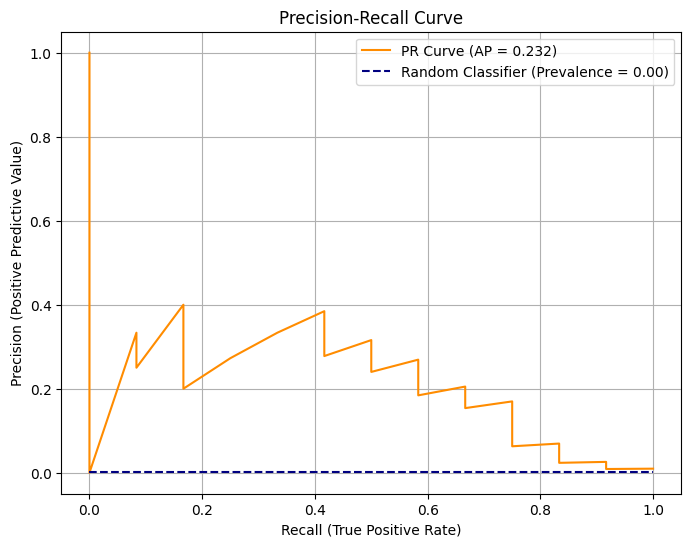

Average Precision (AP) Score: 0.232


In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_svm)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_svm)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

Model Training (RF example)

--- Random Forest Model Training and Evaluation ---

Training Random Forest model...
Random Forest model training complete.

--- Random Forest Model Performance Metrics ---
Accuracy: 0.9989776096513648
AUC: 0.9765585013819225

Classification Report:
               precision    recall  f1-score   support

           0     0.9991    0.9999    0.9995      9769
           1     0.7500    0.2500    0.3750        12

    accuracy                         0.9990      9781
   macro avg     0.8745    0.6249    0.6872      9781
weighted avg     0.9988    0.9990    0.9987      9781



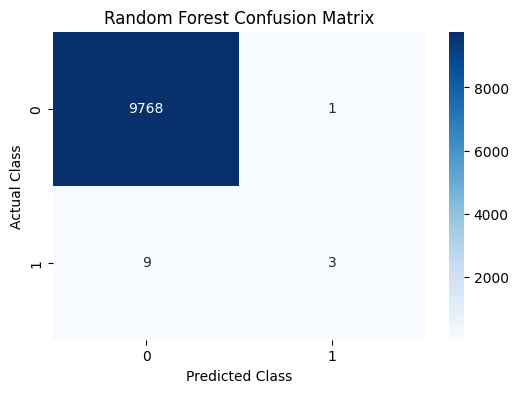

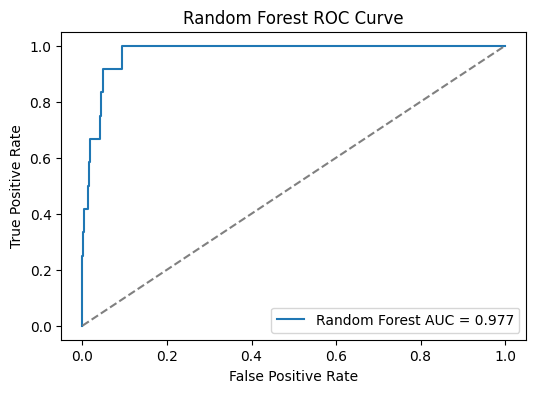

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier # 導入隨機森林分類器

# 假設 X_res_selected, y_res, X_test_selected, y_test 已經從之前的步驟中準備好

print("--- Random Forest Model Training and Evaluation ---")

# 1. 初始化隨機森林模型
# n_estimators: 森林中樹的數量 (通常越多越好，但計算成本會增加)
# max_depth: 每棵樹的最大深度 (None 表示直到所有葉子都是純的，或直到所有葉子包含少於 min_samples_split 個樣本)
# random_state: 隨機種子，確保結果的可重現性
# class_weight: 'balanced' 對於處理不平衡數據集有幫助，儘管我們已經使用了 SMOTE，也可以嘗試。
#               在 SMOTE 後，如果數據仍然有輕微不平衡或希望模型更關注少數類別，可以考慮使用。
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
# 這裡我設定了 n_estimators=200 和 max_depth=10 作為一個合理的起始點，
# 您可以根據實際數據和性能需求進行調整。

# 2. 訓練隨機森林模型
print("\nTraining Random Forest model...")
rf_model.fit(X_res_selected, y_res)
print("Random Forest model training complete.")

# 3. 進行預測
# 預測類別標籤
y_pred_rf = rf_model.predict(X_test_selected)
# 預測正類別的機率
y_prob_rf = rf_model.predict_proba(X_test_selected)[:, 1]

# 4. 評估模型性能 (與 XGBoost 和 SVM 的評估方式相同)
print("\n--- Random Forest Model Performance Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

# 5. 混淆矩陣 (Confusion Matrix)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 6. ROC 曲線 (ROC Curve)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()

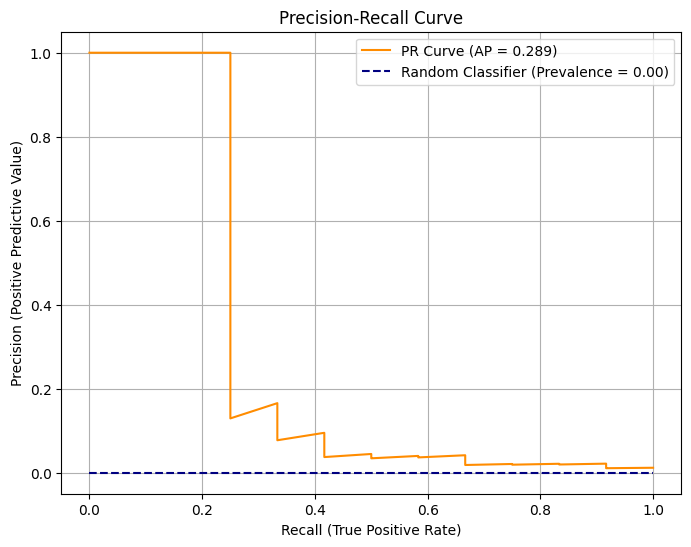

Average Precision (AP) Score: 0.289


In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob_rf)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")